# 5-Fold Cross-Validation — Baseline Model Comparison

Runs each of the 4 baseline architectures (MLP, 1D-CNN, LSTM, Transformer) over **5 grouped folds** built from the 22 train-pool batteries. The 6 test batteries are excluded entirely — test stays untouched for Phase D.

**Why:** single-split val MAE is noisy with only 22 train-pool batteries. K-fold gives per-model mean±std that's robust enough to pick the top-2 for HPO.

**Cost target:** ~8 hours total. Save this as an overnight run.

**Output:** `results/metrics/kfold_summary.json` with per-model, per-fold val MAE/RMSE + mean±std.

In [1]:
import h5py
import json
import math
import os
import sys
import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.dataset import BatterySOHDataset, DEFAULT_TEST_BATTERIES
from src.utils import set_all_seeds
from src.models.mlp import SOHMLP, extract_features
from src.models.cnn1d import SOHCNN1D
from src.models.lstm import SOHLSTM
from src.models.transformer import SOHTransformer

print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')

# --------- global run config ---------
H5_PATH      = '../data/processed/sequences.h5'
STATS_PATH   = '../data/processed/norm_stats.json'
METRICS_PATH = '../results/metrics/kfold_summary.json'

K            = 5
MAX_EPOCHS   = 40    # cap per fold (usually stops earlier via patience)
PATIENCE     = 10
LR           = 1e-3
WEIGHT_DECAY = 1e-4
SEED         = 42

# Per-model batch sizes — match the single-split notebooks.
BATCH_SIZES = {'MLP': 65536, 'CNN': 2048, 'LSTM': 2048, 'Transformer': 512}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs(os.path.dirname(METRICS_PATH), exist_ok=True)

PyTorch 2.7.1+cu118  |  CUDA available: True
Device: cuda


C:\Users\ashin\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load dataset once, compute folds once

In [2]:
# Build folds (excludes test batteries automatically)
folds = BatterySOHDataset.create_kfold_splits(H5_PATH, k=K, seed=SEED)

# Need stats file — compute from the full train pool (union of all fold train+val).
# Equivalent to normalizing with the full 22-battery train pool.
if not os.path.exists(STATS_PATH):
    train_pool_idx = np.concatenate([np.union1d(tr, va) for tr, va in folds[:1]])  # any fold's tr+va = full pool
    train_pool_idx = np.sort(np.unique(np.concatenate([
        np.union1d(tr, va) for tr, va in folds
    ])))
    tmp = BatterySOHDataset(H5_PATH, indices=train_pool_idx, normalize=False)
    tmp.compute_normalization_stats(STATS_PATH)

with open(STATS_PATH) as f:
    stats = json.load(f)
mean = np.array(stats['mean'], dtype=np.float32)
std  = np.array(stats['std'],  dtype=np.float32)

print('Loading full dataset into GPU VRAM...', flush=True)
with h5py.File(H5_PATH, 'r') as f:
    X_all = f['X'][:]            # (N, 301, 3)
    y_all = f['y'][:] / 100.0    # → [0,1]
X_all = (X_all - mean) / (std + 1e-8)
X_gpu = torch.from_numpy(X_all).to(DEVICE)
y_gpu = torch.from_numpy(y_all).to(DEVICE)
del X_all, y_all
torch.cuda.empty_cache()
print(f'X: {tuple(X_gpu.shape)}  |  VRAM: {torch.cuda.memory_allocated()/1024**2:.1f} MiB')

# Precompute MLP features once on GPU (reused across folds).
print('Precomputing MLP features on GPU...', end=' ', flush=True)
with torch.no_grad():
    chunk = 65536
    feats_gpu = torch.cat([
        extract_features(X_gpu[i:i+chunk]) for i in range(0, len(X_gpu), chunk)
    ])
print(f'done. Shape: {tuple(feats_gpu.shape)}')

Fold 0: val batteries=['RW18', 'RW8', 'RW7', 'RW6', 'RW21'] (mean SOH 79.9%, 48,851 samples)  train=319,028 samples from 17 batteries
Fold 1: val batteries=['RW11', 'RW19', 'RW5', 'RW23', 'RW24'] (mean SOH 78.2%, 96,913 samples)  train=270,966 samples from 17 batteries
Fold 2: val batteries=['RW17', 'RW15', 'RW2', 'RW20'] (mean SOH 76.0%, 53,796 samples)  train=314,083 samples from 18 batteries
Fold 3: val batteries=['RW10', 'RW16', 'RW3', 'RW22'] (mean SOH 76.6%, 82,161 samples)  train=285,718 samples from 18 batteries
Fold 4: val batteries=['RW9', 'RW12', 'RW4', 'RW1'] (mean SOH 75.7%, 86,158 samples)  train=281,721 samples from 18 batteries
Loading full dataset into GPU VRAM...
X: (450526, 301, 3)  |  VRAM: 1553.7 MiB
Precomputing MLP features on GPU... done. Shape: (450526, 20)


## 2. Fold-training helper

One routine trains any of the 4 architectures on a single fold. Keeps the loop inline (consistent with `01_mlp.ipynb` / `02_cnn.ipynb` / ... style).

In [3]:
def build_model(name: str) -> nn.Module:
    if name == 'MLP':
        return SOHMLP().net   # bypass extract_features — we precomputed
    if name == 'CNN':
        return SOHCNN1D()
    if name == 'LSTM':
        return SOHLSTM()
    if name == 'Transformer':
        return SOHTransformer()
    raise ValueError(f'unknown model {name!r}')

def train_one_fold(model_name: str, fold_idx: int, train_idx: np.ndarray,
                   val_idx: np.ndarray) -> dict:
    """Train `model_name` on the given fold. Returns best-val metrics + curve."""
    set_all_seeds(SEED + fold_idx, deterministic=False)

    source = feats_gpu if model_name == 'MLP' else X_gpu
    batch = BATCH_SIZES[model_name]

    X_tr, y_tr = source[train_idx], y_gpu[train_idx]
    X_va, y_va = source[val_idx],   y_gpu[val_idx]

    # --- REMOVED DataLoader --- data is already on GPU, no need to copy through CPU
    n_tr = len(X_tr)
    n_batches_tr = (n_tr + batch - 1) // batch

    model = build_model(model_name).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6)
    criterion = nn.MSELoss()
    clip = 1.0 if model_name == 'LSTM' else None

    best_val_mae = float('inf')
    best_val_rmse = float('inf')
    best_epoch = 0
    no_improve = 0
    t0 = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        # -- train --
        model.train()
        running = 0.0
        idx = torch.randperm(n_tr, device=DEVICE)          # shuffle
        for i in range(0, n_tr, batch):
            xb = X_tr[idx[i:i+batch]]
            yb = y_tr[idx[i:i+batch]]
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb).squeeze(1), yb)
            loss.backward()
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            running += loss.item()
        train_loss = running / n_batches_tr

        # -- validate --
        model.eval()
        with torch.no_grad():
            preds = torch.cat([
                model(X_va[i:i+batch]).squeeze(1)
                for i in range(0, len(X_va), batch)
            ]).cpu()
        targets = y_va.cpu()
        preds, targets = preds * 100.0, targets * 100.0
        val_mae  = (preds - targets).abs().mean().item()
        val_rmse = math.sqrt(((preds - targets) ** 2).mean().item())
        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_val_rmse = val_rmse
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    elapsed = time.time() - t0
    return {
        'model': model_name, 'fold': fold_idx,
        'best_val_mae': best_val_mae, 'best_val_rmse': best_val_rmse,
        'best_epoch': best_epoch, 'epochs_run': epoch, 'elapsed_sec': elapsed,
    }

In [4]:
import torch
# This will show you exactly what YOUR python script is using
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")


Allocated: 1588.09 MB


## 3. Run all 4 models × 5 folds

Ordered fastest → slowest so early partial results show up quickly. Partial results are saved after every fold — if the run dies partway through, you don't lose everything.

In [5]:
MODEL_ORDER = ['MLP', 'CNN', 'Transformer', 'LSTM']   # cheap → expensive

all_results: list[dict] = []

def save_partial():
    with open(METRICS_PATH, 'w') as f:
        json.dump({'runs': all_results}, f, indent=2)

for model_name in MODEL_ORDER:
    print(f'\n{"#"*70}\n### {model_name}  (batch={BATCH_SIZES[model_name]})\n{"#"*70}')
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        print(f'\n--- {model_name} fold {fold_idx+1}/{K} ---')
        result = train_one_fold(model_name, fold_idx, tr_idx, va_idx)
        print(f"  best_val_mae={result['best_val_mae']:.4f}% "
              f"best_val_rmse={result['best_val_rmse']:.4f}% "
              f"epoch={result['best_epoch']}/{result['epochs_run']} "
              f"({result['elapsed_sec']:.0f}s)")
        all_results.append(result)
        save_partial()
        # Free per-fold model memory
        torch.cuda.empty_cache()

print('\nAll folds done. Results saved to', METRICS_PATH)


######################################################################
### MLP  (batch=65536)
######################################################################

--- MLP fold 1/5 ---
  best_val_mae=10.5909% best_val_rmse=16.7005% epoch=37/40 (1s)

--- MLP fold 2/5 ---
  best_val_mae=9.8777% best_val_rmse=15.0109% epoch=40/40 (1s)

--- MLP fold 3/5 ---
  best_val_mae=14.4664% best_val_rmse=20.8468% epoch=25/35 (0s)

--- MLP fold 4/5 ---
  best_val_mae=10.6051% best_val_rmse=12.9724% epoch=39/40 (1s)

--- MLP fold 5/5 ---
  best_val_mae=12.5365% best_val_rmse=15.1404% epoch=20/30 (0s)

######################################################################
### CNN  (batch=2048)
######################################################################

--- CNN fold 1/5 ---
  best_val_mae=8.3773% best_val_rmse=16.5081% epoch=23/33 (104s)

--- CNN fold 2/5 ---
  best_val_mae=6.7421% best_val_rmse=12.9506% epoch=32/40 (111s)

--- CNN fold 3/5 ---
  best_val_mae=8.0543% best_val_rmse=15.4704

## 4. Summary — mean ± std per model

In [6]:
import collections

per_model: dict[str, list[dict]] = collections.defaultdict(list)
for r in all_results:
    per_model[r['model']].append(r)

summary: dict[str, dict] = {}
print(f'\n{"Model":>12}  {"Val MAE (mean±std)":>22}  {"Val RMSE (mean±std)":>22}  {"Min MAE":>8}  {"Max MAE":>8}')
print('-' * 82)
for name in MODEL_ORDER:
    runs = per_model.get(name, [])
    if not runs:
        continue
    maes  = np.array([r['best_val_mae']  for r in runs])
    rmses = np.array([r['best_val_rmse'] for r in runs])
    summary[name] = {
        'val_mae_mean':  float(maes.mean()),  'val_mae_std':  float(maes.std(ddof=1)),
        'val_rmse_mean': float(rmses.mean()), 'val_rmse_std': float(rmses.std(ddof=1)),
        'val_mae_min':   float(maes.min()),   'val_mae_max':  float(maes.max()),
        'n_folds':       len(runs),
    }
    print(f'{name:>12}  {maes.mean():>10.4f} ± {maes.std(ddof=1):>6.4f}%  '
          f'{rmses.mean():>10.4f} ± {rmses.std(ddof=1):>6.4f}%  '
          f'{maes.min():>7.4f}%  {maes.max():>7.4f}%')

# Rank by mean val MAE — top 2 go to HPO.
ranked = sorted(summary.items(), key=lambda kv: kv[1]['val_mae_mean'])
print(f'\nRanking by mean val MAE:')
for i, (name, s) in enumerate(ranked, 1):
    tag = '  ← TOP-2 (HPO candidate)' if i <= 2 else ''
    print(f'  {i}. {name:>12}  {s["val_mae_mean"]:.4f} ± {s["val_mae_std"]:.4f}%{tag}')

# Persist full summary.
with open(METRICS_PATH, 'w') as f:
    json.dump({'runs': all_results, 'summary': summary,
               'top2': [name for name, _ in ranked[:2]]}, f, indent=2)
print(f'\nSummary written to {METRICS_PATH}')


       Model      Val MAE (mean±std)     Val RMSE (mean±std)   Min MAE   Max MAE
----------------------------------------------------------------------------------
         MLP     11.6153 ± 1.8753%     16.1342 ± 2.9485%   9.8777%  14.4664%
         CNN      7.4616 ± 1.2750%     12.6417 ± 3.7134%   5.5699%   8.5647%
 Transformer     10.2477 ± 1.4610%     15.2336 ± 2.8853%   9.2890%  12.7258%
        LSTM     10.8751 ± 1.3392%     15.6058 ± 2.7388%   9.7045%  12.7777%

Ranking by mean val MAE:
  1.          CNN  7.4616 ± 1.2750%  ← TOP-2 (HPO candidate)
  2.  Transformer  10.2477 ± 1.4610%  ← TOP-2 (HPO candidate)
  3.         LSTM  10.8751 ± 1.3392%
  4.          MLP  11.6153 ± 1.8753%

Summary written to ../results/metrics/kfold_summary.json


## 5. Quick visualization

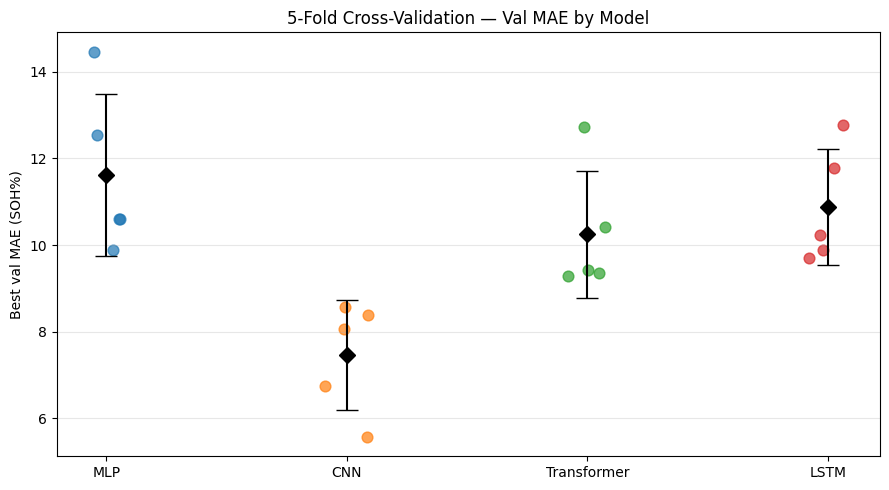

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(MODEL_ORDER):
    if name not in per_model:
        continue
    maes = [r['best_val_mae'] for r in per_model[name]]
    xs = np.full(len(maes), i, dtype=float) + np.random.uniform(-0.1, 0.1, len(maes))
    ax.scatter(xs, maes, s=60, alpha=0.7, label=f'{name} folds')
    ax.errorbar(i, np.mean(maes), yerr=np.std(maes, ddof=1),
                fmt='D', color='black', capsize=8, markersize=8, zorder=5)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Best val MAE (SOH%)')
ax.set_title(f'{K}-Fold Cross-Validation — Val MAE by Model')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('../results/figures/kfold_comparison.png', dpi=150)
plt.show()